## Mock Exam from 2022

#### Introduction

How do I interpret the exam?

#### Import and downloads

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv('Churn_Mock_Exam_1.csv')

#### Preprocessing and general data analysis

In [58]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'IsActiveMember', 'EstimatedSalary', 'Churn', 'Gender_Male',
       'HasCrCard_Yes'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Gender           10000 non-null  object 
 2   Age              10000 non-null  int64  
 3   Tenure           10000 non-null  int64  
 4   Balance          10000 non-null  float64
 5   NumOfProducts    10000 non-null  int64  
 6   HasCrCard        10000 non-null  object 
 7   IsActiveMember   10000 non-null  int64  
 8   EstimatedSalary  10000 non-null  float64
 9   Churn            10000 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 781.4+ KB


In [35]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,199992.480000,1.000000


In [36]:
print('Shape: ', df.shape, 'Size: ', df.size)

Shape:  (10000, 10) Size:  100000


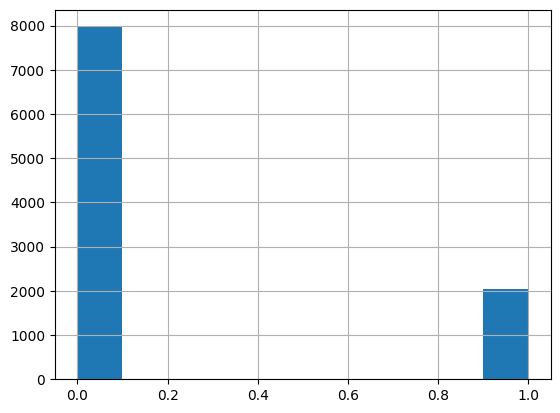

In [37]:
# Distribution of the dependent variable
df['Churn'].hist()
plt.show()

In [38]:
# Create dummy variables for gender and hascrcard
df = pd.get_dummies(df, drop_first = True, dtype = int)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Churn,Gender_Male,HasCrCard_Yes
0,619,42,2,0.00,1,1,101348.88,1,0,1
1,608,41,1,83807.86,1,1,112542.58,0,0,0
2,502,42,8,159660.80,3,0,113931.57,1,0,1
3,699,39,1,0.00,2,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,79084.10,0,0,1


Train-test split

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
y = df['Churn']
X = df[df.drop('Churn', axis = 1).columns]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42, shuffle = True)

In [42]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Gender_Male,HasCrCard_Yes
9254,686,32,6,0.00,2,1,179093.26,1,1
1561,632,42,4,119624.60,2,1,195978.86,1,1
1670,559,24,3,114739.92,1,0,85891.02,1,1
6087,561,27,9,135637.00,1,0,153080.40,0,1
6669,517,56,9,142147.32,1,0,39488.04,1,0
...,...,...,...,...,...,...,...,...,...
5734,768,54,8,69712.74,1,1,69381.05,1,1
5191,682,58,1,0.00,1,1,706.50,0,1
5390,735,38,1,0.00,3,0,92220.12,0,0
860,667,43,8,190227.46,1,0,97508.04,1,1


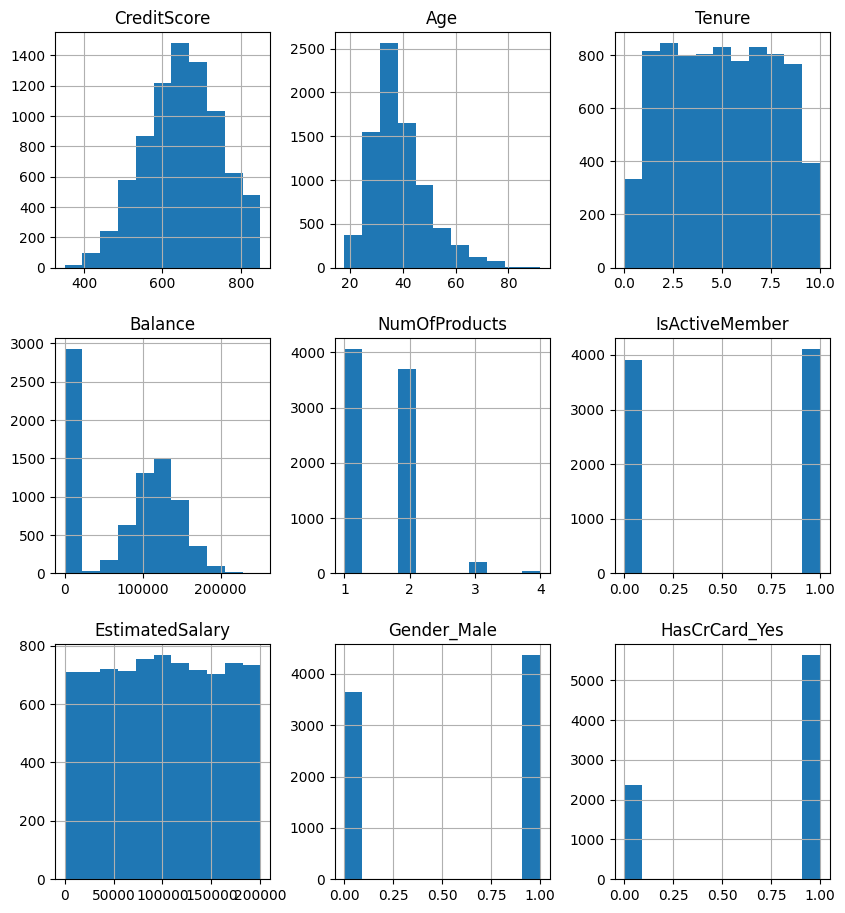

In [43]:
X_train.hist(bins = 11, figsize = (10, 11))
plt.show()

Use correlation to highlight which features are the most relevant for predicting Churn.

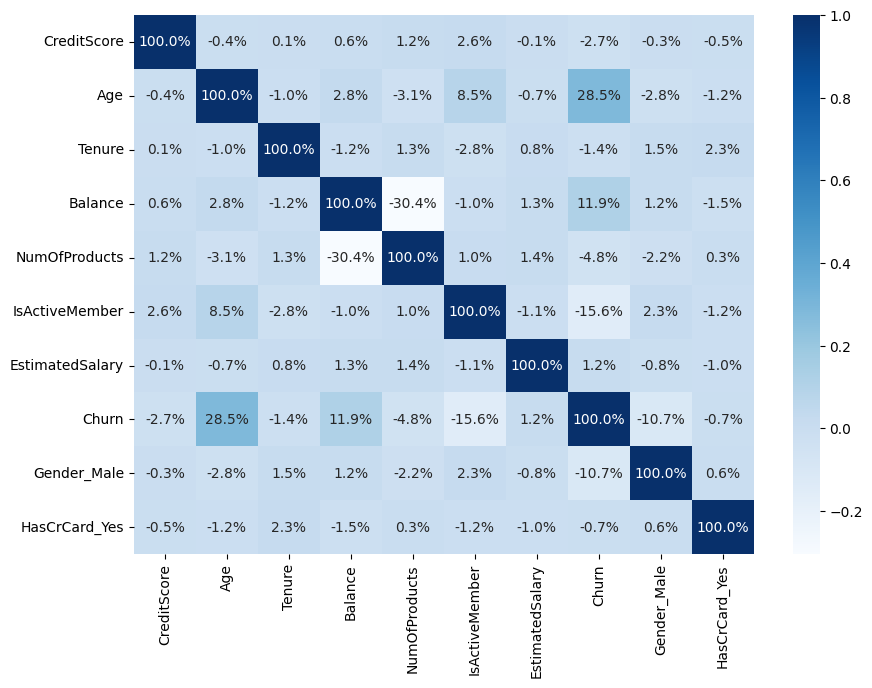

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize = (10, 7))
heatmap(corr_matrix, cmap='Blues', annot=True, fmt='.1%')
plt.show()

#### Modeling and results

Classification modeling tools you can use:
- Logistic Regression
- Naive Bayes
- Decision Tree Classification

Use all and compare.

##### Logistic regression

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix
from seaborn import heatmap

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [48]:
log_model = LogisticRegression().fit(X_train, y_train)

In [50]:
log_pred_train = log_model.predict(X_train)
log_pred_test = log_model.predict(X_test)

In [52]:
print('Accuracy score train: ', accuracy_score(log_pred_train, y_train))
print('Accuracy score test: ', accuracy_score(log_pred_test, y_test))

Accuracy score train:  0.787375
Accuracy score test:  0.8005


Comment on the results.

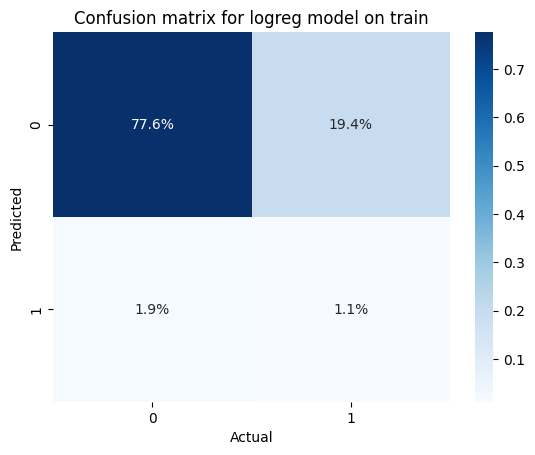

In [68]:
cm_mat = confusion_matrix(log_pred_train, y_train)
heatmap(cm_mat/np.sum(cm_mat), annot=True, fmt='.1%', cmap='Blues')
plt.title('Confusion matrix for logreg model on train')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

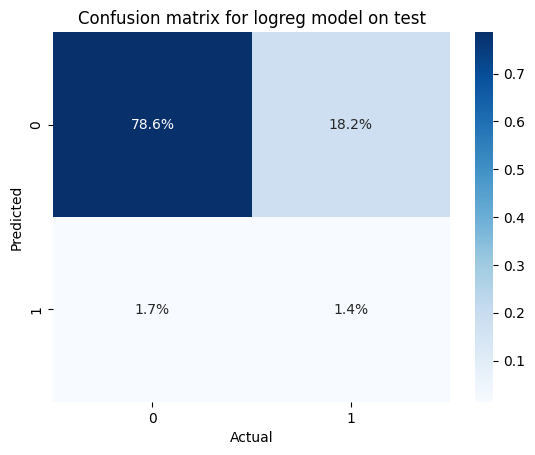

In [69]:
cm_mat = confusion_matrix(log_pred_test, y_test)
heatmap(cm_mat/np.sum(cm_mat), annot=True, fmt='.1%', cmap='Blues')
plt.title('Confusion matrix for logreg model on test')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

##### Naive Bayes Classification

In [60]:
nb_model = GaussianNB().fit(X_train, y_train)

In [61]:
nb_pred_train = nb_model.predict(X_train)
nb_pred_test = nb_model.predict(X_test)

In [62]:
print('Accuracy score train: ', accuracy_score(nb_pred_train, y_train))
print('Accuracy score test: ', accuracy_score(nb_pred_test, y_test))

Accuracy score train:  0.78225
Accuracy score test:  0.79


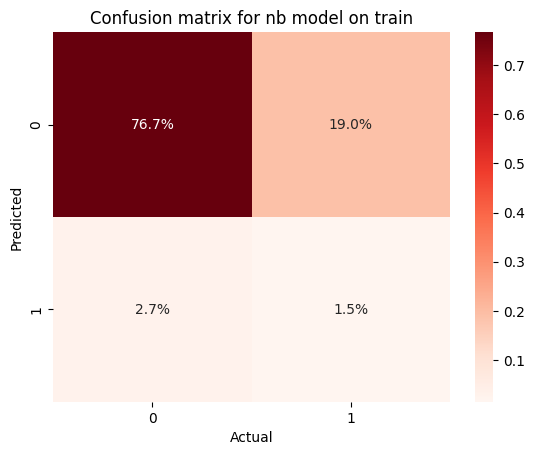

In [71]:
cm_mat = confusion_matrix(nb_pred_train, y_train)
heatmap(cm_mat/np.sum(cm_mat), annot=True, fmt='.1%', cmap='Reds')
plt.title('Confusion matrix for nb model on train')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

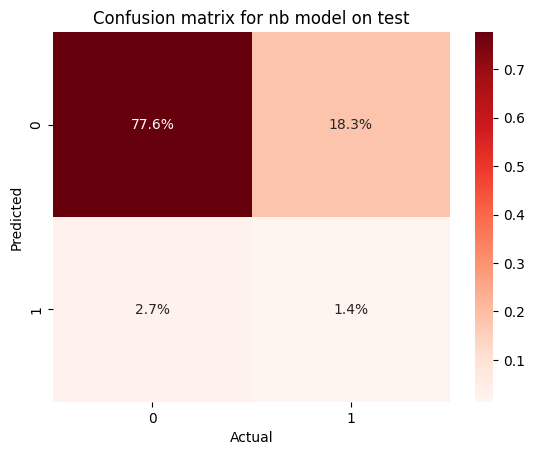

In [72]:
cm_mat = confusion_matrix(nb_pred_test, y_test)
heatmap(cm_mat/np.sum(cm_mat), annot=True, fmt='.1%', cmap='Reds')
plt.title('Confusion matrix for nb model on test')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

When creating conf_matrix the first input is equal to ylabel

##### DTC

In [73]:
dtc_model = DecisionTreeClassifier().fit(X_train, y_train)

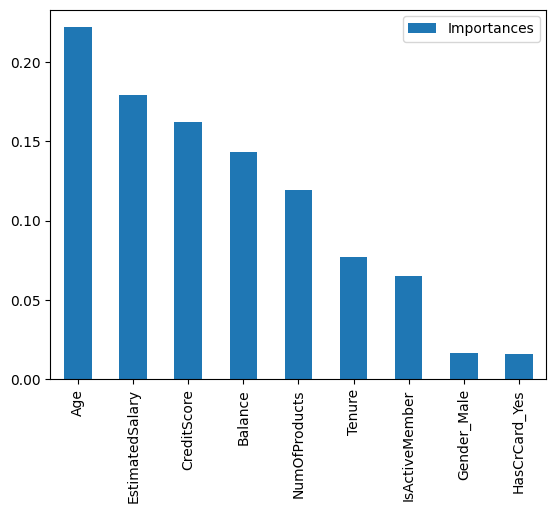

In [75]:
importances = pd.DataFrame(dtc_model.feature_importances_, columns=['Importances'], index=X_train.columns)

importances.sort_values(by=['Importances'], axis=0, ascending=False, inplace=True)

importances.plot(kind='bar')
plt.show()

In [76]:
dtc2_model = DecisionTreeClassifier()

path = dtc2_model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[:-1]

In [77]:
model_list = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha = alpha, random_state = 42)
    model.fit(X_train, y_train)
    model_list.append(model)

In [78]:
train_scores = [model.score(X_train, y_train) for model in model_list]
test_scores = [model.score(X_test, y_test) for model in model_list]

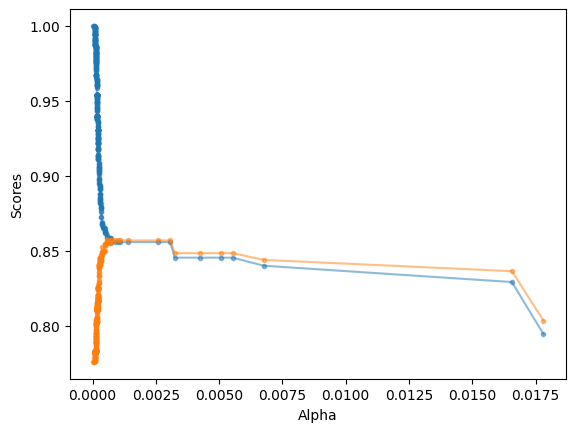

In [79]:
plt.plot(ccp_alphas, train_scores, marker = '.', alpha = 0.5, label = 'train')
plt.plot(ccp_alphas, test_scores, marker = '.', alpha = 0.5, label = 'test')
plt.xlabel('Alpha')
plt.ylabel('Scores')
plt.show()

In [80]:
from sklearn.model_selection import cross_val_score

In [81]:
alpha_loop_values = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=3)
    alpha_loop_values.append([alpha, np.mean(scores), np.std(scores)])

In [82]:
alpha_results = pd.DataFrame(alpha_loop_values, columns=['Alpha', 'Mean Accuracy', 'STDdev'])

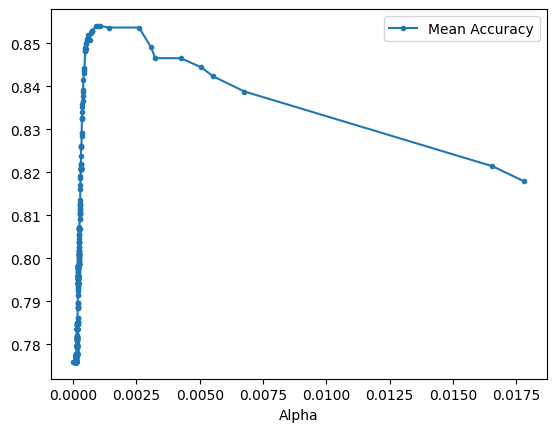

In [83]:
alpha_results.plot(x='Alpha', y='Mean Accuracy', marker = '.')
plt.show()

In [85]:
ideal_alpha = alpha_results[alpha_results['Mean Accuracy'] == max(alpha_results['Mean Accuracy'])].Alpha
ideal_alpha = float(ideal_alpha[471])
ideal_alpha

0.000999964775402878

In [86]:
pruned_model = DecisionTreeClassifier(ccp_alpha=ideal_alpha, random_state=42).fit(X_train, y_train)

In [87]:
pru_pred_train = pruned_model.predict(X_train)
pru_pred_test = pruned_model.predict(X_test)

In [88]:
from sklearn.tree import plot_tree

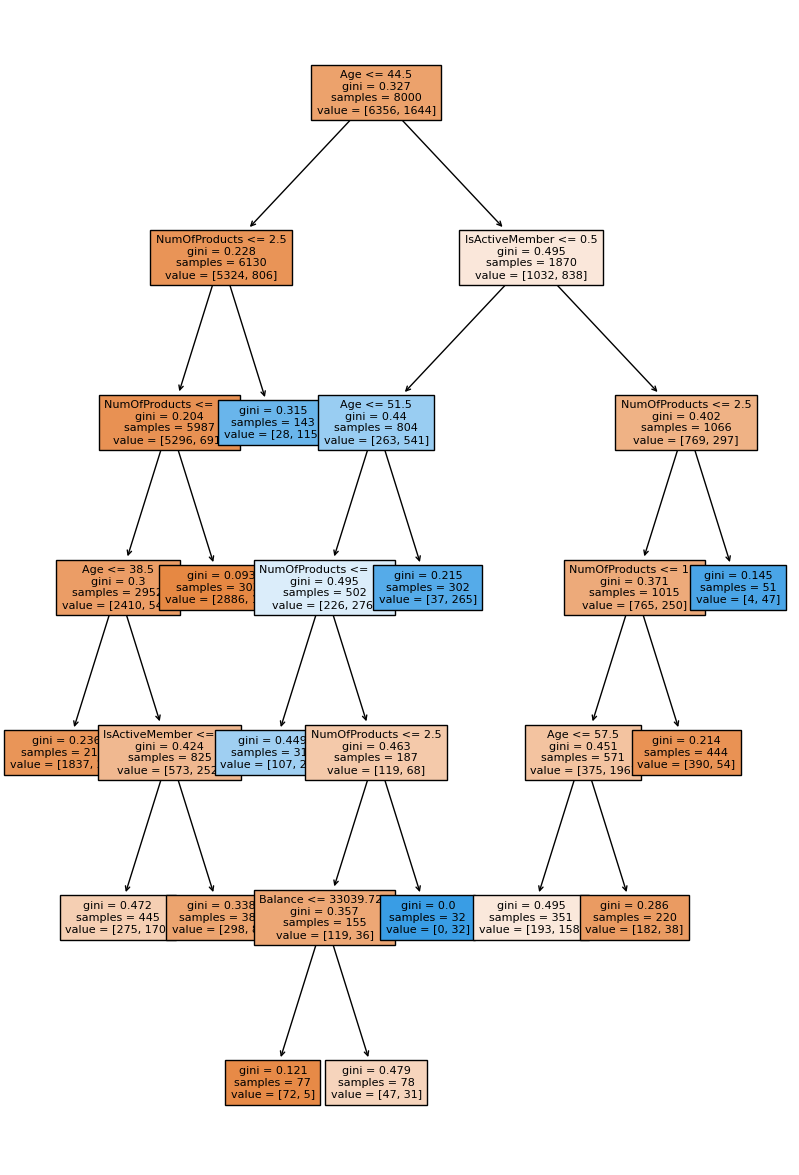

In [89]:
fig = plt.figure(figsize=(10, 15))
plot_tree(pruned_model, feature_names=X_train.columns, filled=True, fontsize=8)
plt.show()

In [90]:
print('Accuracy on DTC train: ', accuracy_score(y_train, pru_pred_train))
print('Accuracy on DTC test: ', accuracy_score(y_test, pru_pred_test))

Accuracy on DTC train:  0.855875
Accuracy on DTC test:  0.857


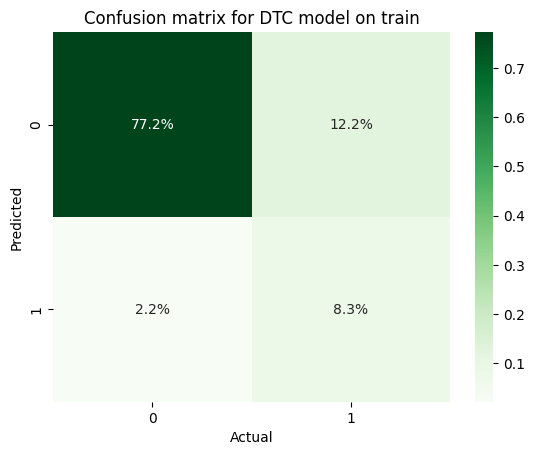

In [91]:
cm_mat = confusion_matrix(pru_pred_train, y_train)
heatmap(cm_mat/np.sum(cm_mat), annot=True, fmt='.1%', cmap='Greens')
plt.title('Confusion matrix for DTC model on train')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

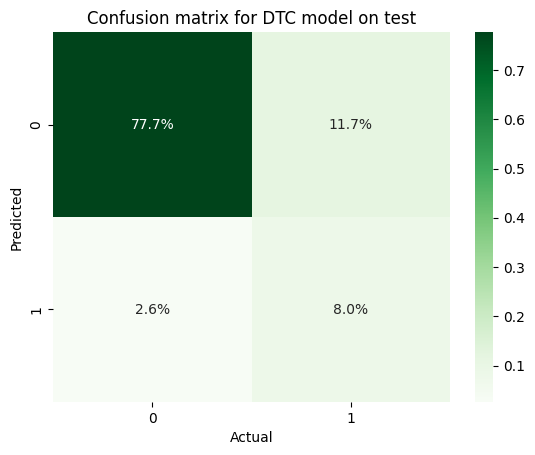

In [92]:
cm_mat = confusion_matrix(pru_pred_test, y_test)
heatmap(cm_mat/np.sum(cm_mat), annot=True, fmt='.1%', cmap='Greens')
plt.title('Confusion matrix for DTC model on test')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

Add ANN model to compare.

#### Discussions

In [ ]:
X_test

#### Conclusions

Decision tree has better results than the other models.

Consistent performance on both train and test sets, not overfitting.

Explain each model